# Compare ollama vs mlx benchmark results
This notebook loads `results/comparison/ollama_vs_mlx_20260602_234525.csv` and compares key metrics across backends and concurrency settings.

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style='whitegrid')

# Load CSV (relative to repo root)
csv_path = '../results/comparison/ollama_vs_mlx_20260602_234525.csv'
df = pd.read_csv(csv_path)
df.head()

,prompt,backend,model,concurrency,requested,success_count,failure_count,avg_latency,min_latency,p50_latency,p95_latency,p99_latency,max_latency,total_tokens,avg_tokens,tokens_per_sec,requests_per_sec,duration
0,What is deep learning?,ollama,qwen2.5:7b,1,16,16,0,1.286808,1.260038,1.276821,1.404204,1.404204,1.404204,708,44.2500,34.387418,0.777117,20.588926
1,What is deep learning?,mlx,qwen2.5:7b,1,16,16,0,2.664858,2.626108,2.645202,2.888071,2.888071,2.888071,752,47.0000,17.636963,0.375255,42.637727
2,What is deep learning?,ollama,qwen2.5:7b,4,16,16,0,3.085882,1.274226,2.518616,4.884855,4.884855,4.884855,707,44.1875,14.319245,0.324056,49.374110
3,What is deep learning?,mlx,qwen2.5:7b,4,16,16,0,10.375420,10.198236,10.300566,10.627914,10.627914,10.627914,752,47.0000,4.529937,0.096382,166.006724
4,What is deep learning?,ollama,qwen2.5:7b,8,16,16,0,5.459892,1.315472,4.865040,9.602166,9.602166,9.602166,700,43.7500,8.012979,0.183154,87.358273


In [5]:
# Convert numeric columns and ensure correct dtypes
num_cols = ['concurrency','requested','success_count','failure_count','avg_latency','min_latency','p50_latency','p95_latency','p99_latency','max_latency','total_tokens','avg_tokens','tokens_per_sec','requests_per_sec','duration']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
df['backend'] = df['backend'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   prompt            8 non-null      str     
 1   backend           8 non-null      category
 2   model             8 non-null      str     
 3   concurrency       8 non-null      int64   
 4   requested         8 non-null      int64   
 5   success_count     8 non-null      int64   
 6   failure_count     8 non-null      int64   
 7   avg_latency       8 non-null      float64 
 8   min_latency       8 non-null      float64 
 9   p50_latency       8 non-null      float64 
 10  p95_latency       8 non-null      float64 
 11  p99_latency       8 non-null      float64 
 12  max_latency       8 non-null      float64 
 13  total_tokens      8 non-null      int64   
 14  avg_tokens        8 non-null      float64 
 15  tokens_per_sec    8 non-null      float64 
 16  requests_per_sec  8 non-null      float64

In [6]:
# Group by backend and concurrency for summarized comparison
group = df.groupby(['backend','concurrency']).agg({
    'avg_latency':'mean',
    'tokens_per_sec':'mean',
    'requests_per_sec':'mean',
    'total_tokens':'sum',
    'success_count':'sum'
}).reset_index()
group

,backend,concurrency,avg_latency,tokens_per_sec,requests_per_sec,total_tokens,success_count
0,mlx,1,2.664858,17.636963,0.375255,752,16
1,mlx,4,10.375420,4.529937,0.096382,752,16
2,mlx,8,20.547557,2.287377,0.048668,752,16
3,mlx,16,41.740975,1.125992,0.023957,752,16
4,ollama,1,1.286808,34.387418,0.777117,708,16
5,ollama,4,3.085882,14.319245,0.324056,707,16
6,ollama,8,5.459892,8.012979,0.183154,700,16
7,ollama,16,10.259636,4.343478,0.097469,713,16


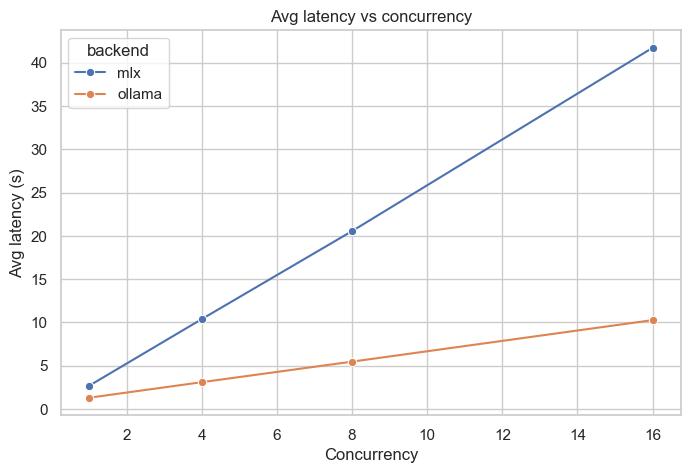

In [7]:
# Avg latency by concurrency
plt.figure(figsize=(8,5))
sns.lineplot(data=group, x='concurrency', y='avg_latency', hue='backend', marker='o')
plt.title('Avg latency vs concurrency')
plt.ylabel('Avg latency (s)')
plt.xlabel('Concurrency')
plt.show()

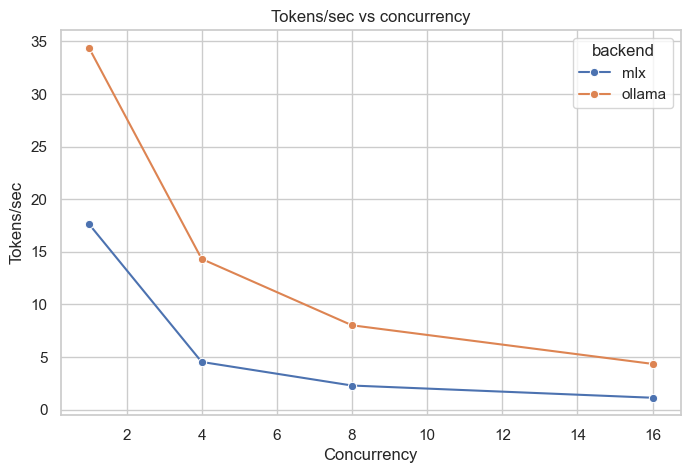

In [8]:
# Tokens/sec by concurrency
plt.figure(figsize=(8,5))
sns.lineplot(data=group, x='concurrency', y='tokens_per_sec', hue='backend', marker='o')
plt.title('Tokens/sec vs concurrency')
plt.ylabel('Tokens/sec')
plt.xlabel('Concurrency')
plt.show()

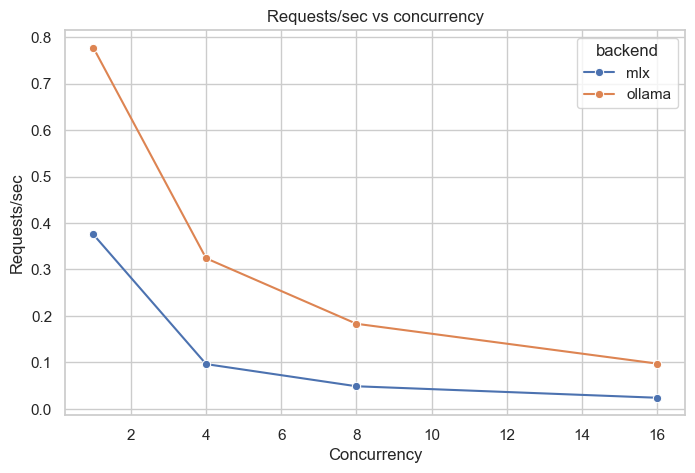

In [9]:
# Requests/sec by concurrency
plt.figure(figsize=(8,5))
sns.lineplot(data=group, x='concurrency', y='requests_per_sec', hue='backend', marker='o')
plt.title('Requests/sec vs concurrency')
plt.ylabel('Requests/sec')
plt.xlabel('Concurrency')
plt.show()

**Next steps**:
- Run the notebook to render plots.
- Adjust plotting or aggregations as needed for deeper analysis.